# Naive Bayes in Machine Learning

### 1. What is Naive Bayes?

Naive Bayes is a supervised machine-learning algorithm mainly used for classification problems.

##### It is based on Bayes' Theorem.

###### Typical applications:

* Spam vs. Not Spam
* Positive vs. Negative sentiment
* Disease classification
* Document/news classification
* Customer category prediction
* Fraud classification
* Text classification

Naive Bayes is called "naive" because it assumes that features are conditionally independent of each other given the class.

##### For example, suppose we want to predict whether an email is spam:

### 2. Bayes' Theorem

The fundamental formula is:

$$ P(A|B)=\frac{P(B|A)P(A)}{P(B)} $$

In machine learning:

$$ P(Class|Features) = \frac{P(Features|Class)P(Class)} {P(Features)} $$

#### Where:

* P(Class | Features) = posterior probability
* P(Features | Class) = likelihood
* P(Class) = prior probability
* P(Features) = evidence

For classification, we compare the probabilities of different classes and select the class with the highest probability.

### 3. Why is it called "Naive"?

Suppose we have:

A Naive Bayes classifier assumes these features are conditionally independent.

In reality:

may have relationships.

But Naive Bayes makes the simplifying assumption:

Each feature contributes independently to the probability of the class.

Despite this simplifying assumption, Naive Bayes often works surprisingly well, particularly for text classification.

##### 4. Types of Naive Bayes

There are several important variants.

| Algorithm       | Suitable data                  |
| --------------- | ------------------------------ |
| `GaussianNB`    | Continuous numerical data      |
| `MultinomialNB` | Counts, text, word frequencies |
| `BernoulliNB`   | Binary 0/1 features            |
| `CategoricalNB` | Categorical features           |
| `ComplementNB`  | Imbalanced text classification |


Let's understand each.

### 5. Gaussian Naive Bayes

Used when features are approximately normally distributed continuous values.

#### Examples:

#### 6. Multinomial Naive Bayes

* Very common for NLP/text classification.

### For example:

We convert text into numerical word counts using:

* CountVectorizer

### Then:

* MultinomialNB()

### is commonly used.

#### 7. Bernoulli Naive Bayes

Used when features are binary:

* 0 = word does not appear
* 1 = word appears

### Example:



### Python:

In [22]:
from sklearn.naive_bayes import BernoulliNB

model = BernoulliNB()

### 8. Categorical Naive Bayes

Used when the input features themselves are categorical.

### Example:

### Python:

In [28]:
from sklearn.naive_bayes import CategoricalNB

model = CategoricalNB()

Categorical features generally need to be encoded into integer categories.

### 9. Complete Naive Bayes ML Workflow

This is the architecture you should remember:

# Example 1 — Student Pass/Fail

Let's start with a simple numerical classification problem.

#### Problem

### Predict whether a student will pass based on:

* Study hours
* Attendance

# Step 1 — Import libraries

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Step 2 — Create dataset

In [39]:
data = {
    "Study_Hours": [
        1, 2, 2, 3, 3,
        4, 4, 5, 5, 6,
        6, 7, 7, 8, 9
    ],

    "Attendance": [
        50, 55, 60, 62, 65,
        68, 70, 72, 75, 78,
        80, 82, 85, 90, 95
    ],

    "Result": [
        0, 0, 0, 0, 0,
        0, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)

print(df)

    Study_Hours  Attendance  Result
0             1          50       0
1             2          55       0
2             2          60       0
3             3          62       0
4             3          65       0
5             4          68       0
6             4          70       1
7             5          72       1
8             5          75       1
9             6          78       1
10            6          80       1
11            7          82       1
12            7          85       1
13            8          90       1
14            9          95       1


### Here:

* 0 = Fail
* 1 = Pass

# Step 3 — Understand dataset

In [43]:
print(df.head())

   Study_Hours  Attendance  Result
0            1          50       0
1            2          55       0
2            2          60       0
3            3          62       0
4            3          65       0


In [45]:
print(df.shape)

(15, 3)


In [47]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_Hours  15 non-null     int64
 1   Attendance   15 non-null     int64
 2   Result       15 non-null     int64
dtypes: int64(3)
memory usage: 492.0 bytes
None


In [49]:
print(df.describe())

       Study_Hours  Attendance     Result
count    15.000000   15.000000  15.000000
mean      4.800000   72.466667   0.600000
std       2.366432   12.855608   0.507093
min       1.000000   50.000000   0.000000
25%       3.000000   63.500000   0.000000
50%       5.000000   72.000000   1.000000
75%       6.500000   81.000000   1.000000
max       9.000000   95.000000   1.000000


# Check missing values:

In [52]:
print(df.isnull().sum())

Study_Hours    0
Attendance     0
Result         0
dtype: int64


# Step 4 — EDA

Check the target:

In [55]:
print(df["Result"].value_counts())

Result
1    9
0    6
Name: count, dtype: int64


We can visualize it

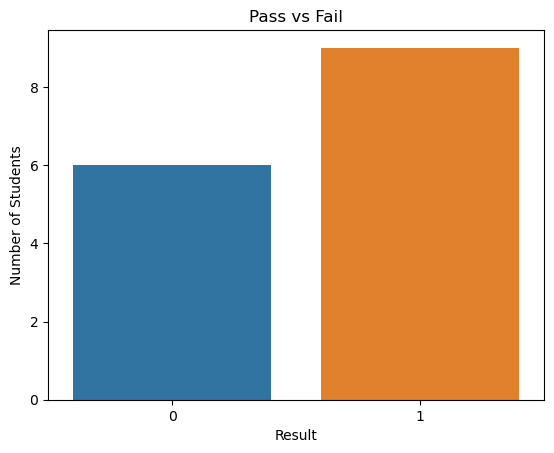

In [60]:
sns.countplot(x="Result", data=df)

plt.title("Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.show()

# Step 5 — Visualization

Study hours vs attendance:

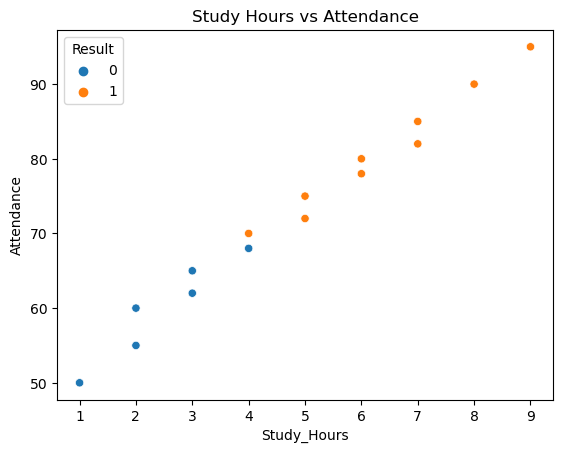

In [63]:
sns.scatterplot(
    x="Study_Hours",
    y="Attendance",
    hue="Result",
    data=df
)

plt.title("Study Hours vs Attendance")
plt.show()

This helps us visually understand whether the classes are separated.

# Step 6 — Separate X and y

In [67]:
X = df[["Study_Hours", "Attendance"]]

y = df["Result"]

# Here:

* X = input/features

* y = target/output

# Step 7 — Train/Test Split

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Suppose we have 15 records.

With:

In [75]:
test_size=0.2

approximately:

# Step 8 — Create Naive Bayes model

Because our features are continuous numerical values:

In [80]:
model = GaussianNB()

# Step 9 — Train

In [83]:
model.fit(X_train, y_train)

GaussianNB()

# Step 10 — Prediction

In [86]:
y_pred = model.predict(X_test)

print(y_pred)

[0 1 1]


# Step 11 — Accuracy

In [89]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


# Step 12 — Confusion Matrix

In [92]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1 0]
 [0 2]]


In [94]:
# Visualize:

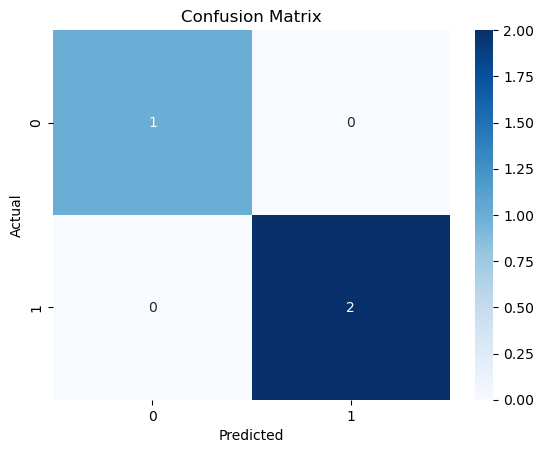

In [96]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Step 13 — Classification Report

In [99]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



### You will see:

* precision
* recall
* f1-score
* support

These are important classification metrics.

# Step 14 — Predict a new student

#### Suppose:

* Study Hours = 6
* Attendance = 85

We can predict:

In [113]:
import warnings
warnings.filterwarnings("ignore")

In [115]:

new_student = [[6, 85]]

prediction = model.predict(new_student)

print(prediction)

[1]


Probability:

In [118]:
probability = model.predict_proba(new_student)

print(probability)

[[1.85279775e-06 9.99998147e-01]]


#### For example, the output may look conceptually like:

## Example 2 — Diabetes Classification

This is a more realistic example.

### Problem

#### Predict whether a patient has diabetes using:

* Glucose
* BMI
* Age
* Blood Pressure

In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


In [124]:
# -----------------------------
# 1. Create dataset
# -----------------------------

data = {
    "Glucose": [
        85, 90, 95, 100, 105,
        110, 115, 120, 125, 130,
        135, 140, 150, 160, 170
    ],

    "BMI": [
        21, 22, 23, 24, 25,
        26, 27, 28, 29, 30,
        31, 32, 33, 34, 35
    ],

    "Age": [
        22, 25, 27, 30, 32,
        35, 37, 40, 42, 45,
        48, 50, 55, 60, 65
    ],

    "BloodPressure": [
        70, 72, 74, 76, 78,
        80, 82, 84, 86, 88,
        90, 92, 94, 96, 98
    ],

    "Diabetes": [
        0, 0, 0, 0, 0,
        0, 0, 1, 1, 1,
        1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)

In [126]:
# -----------------------------
# 2. Dataset understanding
# -----------------------------

print(df.head())


   Glucose  BMI  Age  BloodPressure  Diabetes
0       85   21   22             70         0
1       90   22   25             72         0
2       95   23   27             74         0
3      100   24   30             76         0
4      105   25   32             78         0


In [128]:
print(df.shape)


(15, 5)


In [130]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Glucose        15 non-null     int64
 1   BMI            15 non-null     int64
 2   Age            15 non-null     int64
 3   BloodPressure  15 non-null     int64
 4   Diabetes       15 non-null     int64
dtypes: int64(5)
memory usage: 732.0 bytes
None


In [132]:
print(df.describe())

          Glucose        BMI        Age  BloodPressure   Diabetes
count   15.000000  15.000000  15.000000      15.000000  15.000000
mean   122.000000  28.000000  40.866667      84.000000   0.533333
std     25.620862   4.472136  12.949720       8.944272   0.516398
min     85.000000  21.000000  22.000000      70.000000   0.000000
25%    102.500000  24.500000  31.000000      77.000000   0.000000
50%    120.000000  28.000000  40.000000      84.000000   1.000000
75%    137.500000  31.500000  49.000000      91.000000   1.000000
max    170.000000  35.000000  65.000000      98.000000   1.000000


In [134]:
# -----------------------------
# 3. Missing values
# -----------------------------

print(df.isnull().sum())

Glucose          0
BMI              0
Age              0
BloodPressure    0
Diabetes         0
dtype: int64


In [136]:
# -----------------------------
# 4. EDA
# -----------------------------

print(df["Diabetes"].value_counts())


Diabetes
1    8
0    7
Name: count, dtype: int64


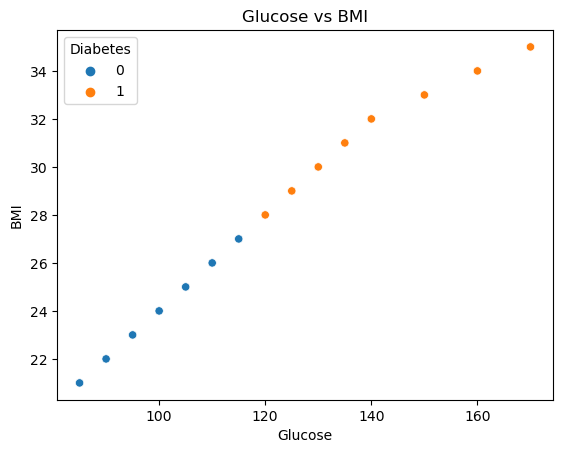

In [138]:
# -----------------------------
# 5. Visualization
# -----------------------------

sns.scatterplot(
    x="Glucose",
    y="BMI",
    hue="Diabetes",
    data=df
)

plt.title("Glucose vs BMI")
plt.show()

In [140]:
# -----------------------------
# 6. X and y
# -----------------------------

X = df[
    [
        "Glucose",
        "BMI",
        "Age",
        "BloodPressure"
    ]
]

y = df["Diabetes"]

In [142]:
# -----------------------------
# 7. Train/Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [144]:
# -----------------------------
# 8. Create model
# -----------------------------

model = GaussianNB()

In [146]:
# -----------------------------
# 9. Train
# -----------------------------

model.fit(X_train, y_train)

GaussianNB()

In [148]:
# -----------------------------
# 10. Prediction
# -----------------------------

y_pred = model.predict(X_test)


In [152]:
# -----------------------------
# 11. Evaluation
# -----------------------------

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)



Accuracy: 0.6666666666666666


In [156]:
print(
    "\nConfusion Matrix:"
)

print(
    confusion_matrix(y_test, y_pred)
)




Confusion Matrix:
[[0 1]
 [0 2]]


In [158]:
print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_test,
        y_pred
    )
)



Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



In [162]:
# -----------------------------
# 12. New patient
# -----------------------------

new_patient = [[
    145,   # Glucose
    32,    # BMI
    50,    # Age
    90     # Blood Pressure
]]

prediction = model.predict(new_patient)

probability = model.predict_proba(new_patient)

print("Prediction:", prediction)
print("Probability:", probability)


Prediction: [1]
Probability: [[1.50437431e-21 1.00000000e+00]]


# Important note

This tiny dataset is illustrative only. It should not be used to make medical decisions. For a real ML project, use a proper dataset and clinically appropriate evaluation.

## Example 3 — Spam Email Detection

This is one of the most important Naive Bayes applications.

### Here we use:

* MultinomialNB

because we're dealing with text.

### Problem

##### Predict:

* Spam
* Not Spam

from email messages.

# Step 1 — Dataset

In [168]:
import pandas as pd

data = {
    "Message": [
        "Win free money now",
        "Congratulations you won lottery",
        "Free offer click now",
        "Claim your free prize",
        "Win cash prize today",
        "Let's meet tomorrow",
        "Can you send the report",
        "Meeting is scheduled at 10",
        "Please call me later",
        "Project meeting tomorrow"
    ],

    "Label": [
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "ham",
        "ham",
        "ham",
        "ham",
        "ham"
    ]
}

df = pd.DataFrame(data)

print(df)

                           Message Label
0               Win free money now  spam
1  Congratulations you won lottery  spam
2             Free offer click now  spam
3            Claim your free prize  spam
4             Win cash prize today  spam
5              Let's meet tomorrow   ham
6          Can you send the report   ham
7       Meeting is scheduled at 10   ham
8             Please call me later   ham
9         Project meeting tomorrow   ham


# Step 2 — Convert text to numbers

Machine-learning algorithms cannot directly understand:

* "Win free money"

We need to convert text into numerical features.

### Use:

CountVectorizer

In [174]:
from sklearn.feature_extraction.text import CountVectorizer

# Create vectorizer:

In [177]:
vectorizer = CountVectorizer()

### Transform text:

In [180]:
X = vectorizer.fit_transform(df["Message"])

# Step 3 — Target

In [183]:
y = df["Label"]

# Step 4 — Train/Test Split

In [186]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Step 5 — Multinomial Naive Bayes

In [189]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

# Step 6 — Train

In [192]:
model.fit(X_train, y_train)

MultinomialNB()

# Step 7 — Predict

In [195]:
y_pred = model.predict(X_test)

print(y_pred)

['ham' 'spam']


# Step 8 — Evaluate

In [198]:
from sklearn.metrics import accuracy_score

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

Accuracy: 1.0


# Complete example:

In [201]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Dataset

data = {
    "Message": [
        "Win free money now",
        "Congratulations you won lottery",
        "Free offer click now",
        "Claim your free prize",
        "Win cash prize today",
        "Let's meet tomorrow",
        "Can you send the report",
        "Meeting is scheduled at 10",
        "Please call me later",
        "Project meeting tomorrow"
    ],

    "Label": [
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "ham",
        "ham",
        "ham",
        "ham",
        "ham"
    ]
}

df = pd.DataFrame(data)

# X and y

X_text = df["Message"]
y = df["Label"]

# Text → numerical features

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(X_text)

# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model

model = MultinomialNB()

# Training

model.fit(X_train, y_train)

# Prediction

y_pred = model.predict(X_test)

# Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# New message

new_message = [
    "You won free cash prize"
]

new_message_vector = vectorizer.transform(new_message)

prediction = model.predict(new_message_vector)

print("Prediction:", prediction)

Accuracy: 1.0

Confusion Matrix:
[[1 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         1
        spam       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

Prediction: ['spam']


# Example 4 — Sentiment Analysis

Now let's use Naive Bayes for NLP.

## Problem

## Predict:

* Positive
* Negative

# Dataset

In [207]:
import pandas as pd

data = {
    "Review": [
        "This movie is excellent",
        "Amazing movie and great acting",
        "I loved this movie",
        "Fantastic experience",
        "Very good movie",
        "This movie is terrible",
        "I hated this movie",
        "Very boring movie",
        "Worst movie ever",
        "Terrible acting"
    ],

    "Sentiment": [
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative"
    ]
}

df = pd.DataFrame(data)

In [209]:
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# X and y

X_text = df["Review"]

y = df["Sentiment"]

# Convert text to TF-IDF

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X_text)

# Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model

model = MultinomialNB()

# Train

model.fit(X_train, y_train)

# Predict

y_pred = model.predict(X_test)

# Evaluation

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    confusion_matrix(y_test, y_pred)
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

# New review

new_review = [
    "This movie was fantastic and amazing"
]

new_vector = vectorizer.transform(new_review)

prediction = model.predict(new_vector)

print("Sentiment:", prediction)

Accuracy: 0.5
[[1 0]
 [1 0]]
              precision    recall  f1-score   support

    negative       0.50      1.00      0.67         1
    positive       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

Sentiment: ['positive']


# Example 5 — Gaussian Naive Bayes with Iris Dataset

This is an excellent example for practicing a real built-in dataset.

### We will predict:

* Setosa
* Versicolor
* Virginica

### using:

* Sepal Length
* Sepal Width
* Petal Length
* Petal Width

In [212]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [214]:
# --------------------------------
# 1. Load dataset
# --------------------------------

iris = load_iris()

In [216]:
# --------------------------------
# 2. Create DataFrame
# --------------------------------

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [218]:
# --------------------------------
# 3. Dataset information
# --------------------------------

print(df.shape)

print(df.info())

print(df.describe())


(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.30000

In [220]:
# --------------------------------
# 4. Check missing values
# --------------------------------

print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [222]:
# --------------------------------
# 5. EDA
# --------------------------------

print(df["target"].value_counts())


target
0    50
1    50
2    50
Name: count, dtype: int64


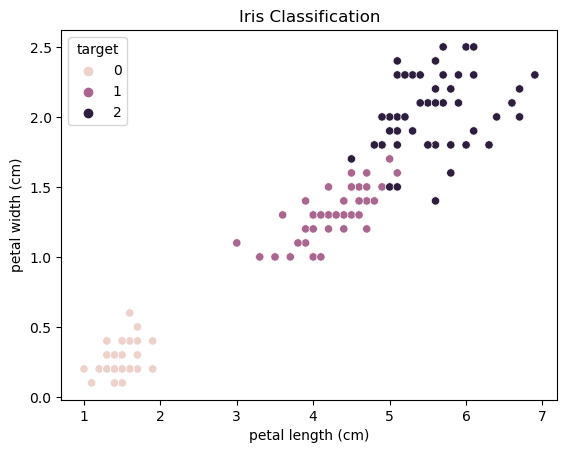

In [224]:
# --------------------------------
# 6. Visualization
# --------------------------------

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="target"
)

plt.title("Iris Classification")
plt.show()


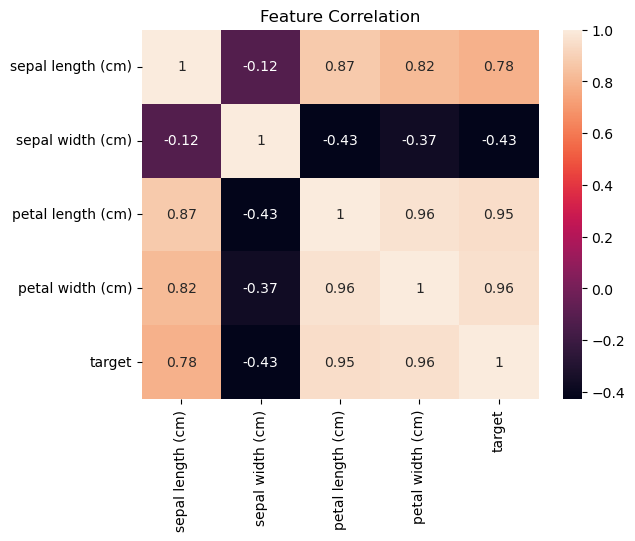

In [226]:
# --------------------------------
# 7. Correlation
# --------------------------------

sns.heatmap(
    df.corr(),
    annot=True
)

plt.title("Feature Correlation")
plt.show()

In [228]:
# --------------------------------
# 8. X and y
# --------------------------------

X = df.drop(
    "target",
    axis=1
)

y = df["target"]

In [230]:
# --------------------------------
# 9. Train/Test Split
# --------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [232]:
# --------------------------------
# 10. Model
# --------------------------------

model = GaussianNB()

In [234]:
# --------------------------------
# 11. Training
# --------------------------------

model.fit(
    X_train,
    y_train
)

GaussianNB()

In [236]:
# --------------------------------
# 12. Prediction
# --------------------------------

y_pred = model.predict(X_test)

In [238]:
# --------------------------------
# 13. Accuracy
# --------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.9666666666666667


[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


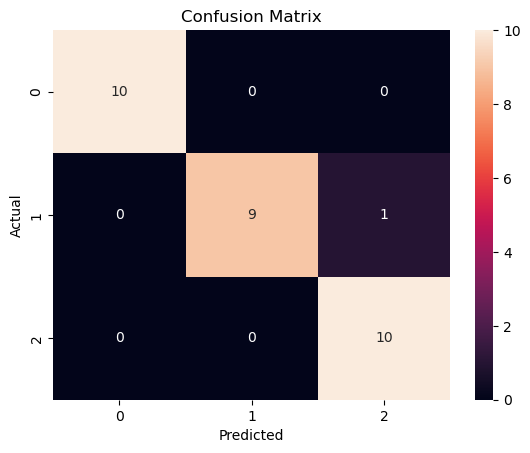

In [240]:
# --------------------------------
# 14. Confusion Matrix
# --------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [242]:
# --------------------------------
# 15. Classification Report
# --------------------------------

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [244]:
# --------------------------------
# 16. New flower
# --------------------------------

new_flower = [[
    5.1,
    3.5,
    1.4,
    0.2
]]

prediction = model.predict(
    new_flower
)

print(
    "Predicted class:",
    prediction
)

print(
    "Flower name:",
    iris.target_names[prediction][0]
)

Predicted class: [0]
Flower name: setosa


# 10. When Should You Use Which Naive Bayes?

This is extremely important for interviews.

| Data                 | Naive Bayes     |
| -------------------- | --------------- |
| Continuous numerical | `GaussianNB`    |
| Word counts          | `MultinomialNB` |
| Binary 0/1 features  | `BernoulliNB`   |
| Categorical features | `CategoricalNB` |
| Imbalanced text      | `ComplementNB`  |


# 11. Naive Bayes vs Other Algorithms

| Algorithm           | Main strength                     |
| ------------------- | --------------------------------- |
| Logistic Regression | Simple classification             |
| Decision Tree       | Rules and interpretability        |
| Random Forest       | Strong general-purpose model      |
| KNN                 | Similarity-based classification   |
| SVM                 | Complex boundaries                |
| Naive Bayes         | Fast probabilistic classification |
| XGBoost             | High-performance tabular ML       |


Naive Bayes is particularly useful when:

* dataset is large
* training needs to be fast
* you are working with text
* you need a strong baseline
* features are high-dimensional
* you need probability estimates

# 12. Advantages
1. Very fast

Training and prediction are generally fast.

2. Works well with high-dimensional data

Especially useful for text:

10,000+
words/features

3. Requires relatively little training data


### 4. Simple implementation
model = GaussianNB()

model.fit(X_train, y_train)

model.predict(X_test)

# 5. Supports multiclass classification

For example:

# 13. Disadvantages
1. Independence assumption

This is the biggest limitation.

Naive Bayes assumes:

are conditionally independent.

That may not be true in real-world data.

## 2. Zero-frequency problem

Suppose a particular word never appeared in a particular class.

Its probability could become:

0

This can cause problems.

Naive Bayes implementations commonly use smoothing, such as Laplace smoothing, to address this.

For example:

In [260]:
MultinomialNB(alpha=1.0)

MultinomialNB()

# 14. Does Naive Bayes Need Feature Scaling?

Usually no.

For example, with:

In [263]:
GaussianNB()

GaussianNB()

you normally don't need:

StandardScaler()

just because the values have different scales.

This is different from algorithms such as:

* KNN
* SVM
* Logistic Regression

where scaling can be important.

However, preprocessing requirements depend on the specific Naive Bayes variant and data representation.

# 15. Cross Validation

After the basic train/test experiment, you can evaluate the model using cross-validation.

In [271]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    GaussianNB(),
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Scores:", scores)

print(
    "Mean Accuracy:",
    scores.mean()
)

Scores: [0.93333333 0.96666667 0.93333333 0.93333333 1.        ]
Mean Accuracy: 0.9533333333333334


Conceptually:

This gives a more reliable estimate than relying on only one train/test split.

# 16. Hyperparameter Tuning

Naive Bayes has fewer hyperparameters than many algorithms.

For MultinomialNB, an important parameter is:

In [277]:
###  alpha

# Example:

from sklearn.model_selection import GridSearchCV

parameters = {
    "alpha": [0.01, 0.1, 0.5, 1.0, 2.0]
}

In [279]:
model = MultinomialNB()

grid = GridSearchCV(
    model,
    parameters,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=MultinomialNB(),
             param_grid={'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]},
             scoring='accuracy')

In [281]:
# Best parameters:

print(grid.best_params_)

# Best model:

final_model = grid.best_estimator_# 

{'alpha': 0.5}


# 17. Save the Model

Once you've finalized the model:

In [284]:
import joblib

joblib.dump(
    model,
    "naive_bayes_model.pkl"
)

['naive_bayes_model.pkl']

In [286]:
## For a text classifier, you should also save the vectorizer:

joblib.dump(
    vectorizer,
    "vectorizer.pkl"
)

['vectorizer.pkl']

# 18. Load the Model

# 19. Complete Project Architecture

For your ML practice, remember this structure:

## What you should practice next

For Naive Bayes, I recommend practicing these 5 projects in this order:

* Student Pass/Fail → GaussianNB
* Diabetes Classification → GaussianNB
* Spam Email Detection → MultinomialNB
* Sentiment Analysis → MultinomialNB
* Iris Classification → GaussianNB

Then move to a real CSV dataset and practice the complete pipeline: data cleaning → EDA → visualization → feature engineering → train/test split → Naive Bayes → confusion matrix → precision/recall/F1 → cross-validation → hyperparameter tuning → model saving → new-data prediction.